   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa


C:\Users\siddh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



--- Single-Layer Perceptron ---
Accuracy : 83.33%
              precision    recall  f1-score   support

           0       0.77      1.00      0.87        10
           1       1.00      0.44      0.62         9
           2       0.85      1.00      0.92        11

    accuracy                           0.83        30
   macro avg       0.87      0.81      0.80        30
weighted avg       0.87      0.83      0.81        30


--- Multi-Layer Perceptron ---
Accuracy : 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


--- Model Comparison ---
Model                            Accuracy
------------------------------------------
Single-Layer Perceptron  

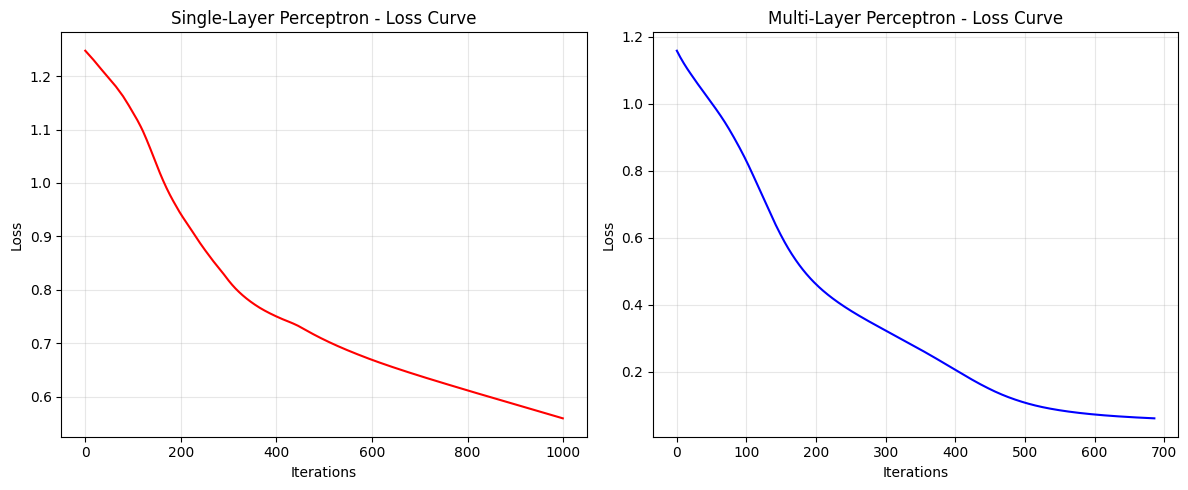

In [38]:
# ============================================================
#   SINGLE-LAYER & MULTI-LAYER PERCEPTRON
#   Dataset: Iris
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load Dataset
df = pd.read_csv("Iris-ex-9,13.csv")
df.drop(columns=["Id"], inplace=True)
print(df.head())

# 2. Features & Target
X = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]
y = LabelEncoder().fit_transform(df["Species"])  # convert to numbers

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Scaling (important for neural networks!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ── SINGLE-LAYER PERCEPTRON (1 hidden layer with 1 neuron) ──
slp = MLPClassifier(hidden_layer_sizes=(1,), max_iter=1000, random_state=42)
slp.fit(X_train, y_train)
y_pred_slp = slp.predict(X_test)

print("\n--- Single-Layer Perceptron ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_slp) * 100:.2f}%")
print(classification_report(y_test, y_pred_slp))

# ── MULTI-LAYER PERCEPTRON (2 hidden layers) ──
mlp = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

print("\n--- Multi-Layer Perceptron ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_mlp) * 100:.2f}%")
print(classification_report(y_test, y_pred_mlp))

# ── MODEL COMPARISON ──
print("\n--- Model Comparison ---")
print(f"{'Model':<30} {'Accuracy':>10}")
print("-" * 42)
print(f"{'Single-Layer Perceptron':<30} {accuracy_score(y_test, y_pred_slp)*100:>9.2f}%")
print(f"{'Multi-Layer Perceptron':<30} {accuracy_score(y_test, y_pred_mlp)*100:>9.2f}%")

# ── PLOT ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 - Loss Curve SLP
axes[0].plot(slp.loss_curve_, color='red')
axes[0].set_title("Single-Layer Perceptron - Loss Curve")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

# Plot 2 - Loss Curve MLP
axes[1].plot(mlp.loss_curve_, color='blue')
axes[1].set_title("Multi-Layer Perceptron - Loss Curve")
axes[1].set_xlabel("Iterations")
axes[1].set_ylabel("Loss")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 